#clear recognisation

1. Input Frame (CCTV/Webcam)
2. MTCNN detects faces
3. Each face cropped and aligned
4. Convert to tensor
5. Pass through InceptionResNetV1
6. Generate embedding
7. Compare with stored embeddings
8. Compute minimum Euclidean distance
9. Convert to confidence score
10. Display Name + Confidence on screen


In [61]:
# Mount Google Drive to access dataset and store outputs

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
# Extract the uploaded dataset (faces_dataset.zip) into /content
!unzip "/content/drive/MyDrive/faces_dataset.zip" -d "/content/"


Archive:  /content/drive/MyDrive/faces_dataset.zip
replace /content/face_dataset/aditya/mask/WhatsApp Image 2025-11-21 at 12.54.30_0bc329c5.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!pip uninstall -y pillow
!pip install pillow==9.5.0
!pip install facenet-pytorch


Found existing installation: pillow 11.3.0
Uninstalling pillow-11.3.0:
  Successfully uninstalled pillow-11.3.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 MB 20.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pillow: filename=Pillow-9.5.0-cp312-cp312-linux_x86_64.whl size=1210318 sha256=f7f4a2bf6f1c362d6e0a1ebcf1850fa8ecd5bca7fdb9fce326f9bcb5a8dbf518
  Stored in directory: /root/.cache/pip/wheels/ea/de/2e/75a6399e5d8cd3a55c13c8f0658d996d4ce4cff37389de044c
Successfully built pillow
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 9.5.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [ ]:
# ===============================
# INSTALL DEPENDENCIES
# ===============================
!pip install facenet-pytorch mtcnn numpy opencv-python

import torch
import numpy as np
import cv2
import pickle
from facenet_pytorch import MTCNN, InceptionResnetV1
from PIL import Image



INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.12.0.88
    Uninstalling opencv-python-4.12.0.88:
      Successfully uninstalled opencv-python-4.12.0.88


In [63]:
import torch              # For deep learning model execution
import numpy as np        # For numerical operations and embedding distance compute
import cv2                # For drawing rectangles and text on images
import pickle             # For saving/loading embeddings
from facenet_pytorch import MTCNN, InceptionResnetV1  # Face detector + embedding model
from PIL import Image     # For reading and cropping images

📸 Take Live Photo from Laptop Camera

In [64]:
from IPython.display import Javascript, display
from google.colab.output import eval_js
from base64 import b64decode

# Function to capture image from webcam in Colab

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = '📸 Capture';
          div.appendChild(capture);
          document.body.appendChild(div);

          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          document.body.appendChild(video);
          video.srcObject = stream;
          await video.play();

          // Wait for button click
          await new Promise((resolve) => capture.onclick = resolve);

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getVideoTracks()[0].stop();

          const dataUrl = canvas.toDataURL('image/jpeg', quality);
          div.remove();
          video.remove();
          return dataUrl;
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

         # Save image to disk

    with open(filename, 'wb') as f:
        f.write(binary)
    return filename


# Capture image


In [67]:
filename = take_photo()
print("📷 Photo saved as:", filename)



<IPython.core.display.Javascript object>

📷 Photo saved as: photo.jpg


In [68]:
!pip install retina-face


Why Your Model is Strong (USP)

Works with low images per user

Works with masked faces

No retraining required

Fast enough for CCTV

Human-interpretable score

Embeddings make it scalable

Industry-level architecture

1.Capture image

2.Detect face using MTCNN

3.Crop face

4.Convert to embedding using FaceNet

5.Compare embedding with stored embeddings using Euclidean distance

6.Lowest distance → best match

7.If distance < threshold → recognized

8.Else → unknown

In [50]:
# What makes this system special?

# Works with very few images per person

# Works for mask and no-mask cases

# Real embeddings, not simple CNN classification

# Works offline (no internet or cloud)

In [69]:
# ===============================
# BUILDING EMBEDDING DATABASE
# ===============================

import os
import torch
import pickle
import numpy as np
from PIL import Image
from torchvision import transforms
from facenet_pytorch import InceptionResnetV1

# ---------------------------
# 1. SET DATASET PATH
# ---------------------------
dataset_path = "/content/drive/My Drive/face_dataset"
output_pickle = "/content/drive/My Drive/face_embeddings.pkl"

# ---------------------------
# 2. LOAD FACENET MODEL
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = InceptionResnetV1(pretrained='vggface2').eval().to(device)

# ---------------------------
# 3. IMAGE PREPROCESSOR
# ---------------------------
transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
])

# ---------------------------
# 4. START BUILDING DB
# ---------------------------
embedding_database = {}

for person in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person)

    if not os.path.isdir(person_path):
        continue

    print(f"\nProcessing person: {person}")
    embeddings = []

    for sub in ["mask", "unmask"]:
        sub_path = os.path.join(person_path, sub)
        if not os.path.isdir(sub_path):
            continue

        for img_name in os.listdir(sub_path):
            img_path = os.path.join(sub_path, img_name)

            # Skip folders or non-images
            if os.path.isdir(img_path):
                continue
            if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            try:
                img = Image.open(img_path).convert("RGB")
                img_tensor = transform(img).unsqueeze(0).to(device)

                with torch.no_grad():
                    emb = model(img_tensor).cpu().numpy()[0]

                embeddings.append(emb)
                print("✔ Embedded:", img_path)

            except Exception as e:
                print("⚠ Error:", img_path, e)

    if len(embeddings) > 0:
        embedding_database[person] = embeddings
        print(f"🎯 Stored {len(embeddings)} embeddings for {person}")
    else:
        print(f"❌ No valid images for {person}")

# ---------------------------
# 5. SAVE TO DISK
# ---------------------------
with open(output_pickle, "wb") as f:
    pickle.dump(embedding_database, f)

print("\n🎉 All embeddings saved at:", output_pickle)



Processing person: aditya
✔ Embedded: /content/drive/My Drive/face_dataset/aditya/mask/WhatsApp Image 2025-11-21 at 12.54.31_976ead59.jpg
✔ Embedded: /content/drive/My Drive/face_dataset/aditya/mask/WhatsApp Image 2025-11-21 at 12.54.32_d9c03418.jpg
✔ Embedded: /content/drive/My Drive/face_dataset/aditya/mask/WhatsApp Image 2025-11-21 at 12.54.30_0bc329c5.jpg
✔ Embedded: /content/drive/My Drive/face_dataset/aditya/unmask/aditya.jpg
✔ Embedded: /content/drive/My Drive/face_dataset/aditya/unmask/WhatsApp Image 2025-11-21 at 12.54.33_defac223.jpg
✔ Embedded: /content/drive/My Drive/face_dataset/aditya/unmask/WhatsApp Image 2025-11-21 at 12.54.34_18ffa9eb.jpg
✔ Embedded: /content/drive/My Drive/face_dataset/aditya/unmask/WhatsApp Image 2025-11-21 at 12.54.35_e541d4df.jpg
🎯 Stored 7 embeddings for aditya

Processing person: anshika
✔ Embedded: /content/drive/My Drive/face_dataset/anshika/mask/WhatsApp Image 2025-11-21 at 12.55.19_7706d8fb.jpg
✔ Embedded: /content/drive/My Drive/face_datase

In [70]:
# create_database.py
import os
import pickle
import numpy as np
import torch
from PIL import Image
from facenet_pytorch import MTCNN, InceptionResnetV1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# MTCNN configured to return aligned 160x160 face tensors
mtcnn = MTCNN(image_size=160, margin=0, keep_all=False, post_process=True, device=device)

# FaceNet model
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

dataset_path = "/content/drive/My Drive/face_dataset"
out_path = "/content/drive/My Drive/face_embeddings_mean.pkl"

database = {}

for person in os.listdir(dataset_path):
    person_dir = os.path.join(dataset_path, person)
    if not os.path.isdir(person_dir):
        continue

    print(f"\nProcessing: {person}")
    emb_list = []

    # traverse mask & unmask subfolders (if you have others, os.walk is fine)
    for sub in ["mask", "unmask"]:
        sub_dir = os.path.join(person_dir, sub)
        if not os.path.isdir(sub_dir):
            continue

        for fname in os.listdir(sub_dir):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            img_path = os.path.join(sub_dir, fname)
            try:
                img = Image.open(img_path).convert("RGB")
            except Exception as e:
                print("  Failed open:", img_path, e)
                continue

            # detect & get aligned face tensor (3x160x160) or None
            face_tensor = mtcnn(img)   # returns torch.Tensor (3,160,160) or None

            if face_tensor is None:
                print("  No face detected:", img_path)
                continue

            # Prepare batch dim and get embedding
            face_tensor = face_tensor.unsqueeze(0).to(device)   # (1,3,160,160)
            with torch.no_grad():
                emb = resnet(face_tensor)                       # (1,512)
            emb = emb.cpu().numpy().reshape(-1)

            # Normalize (L2)
            emb = emb / np.linalg.norm(emb)
            emb_list.append(emb)
            print("  Embedded:", img_path)

    if len(emb_list) == 0:
        print("  WARNING: no valid faces for", person)
        continue

    # Compute mean (centroid) and normalize again
    mean_emb = np.mean(np.vstack(emb_list), axis=0)
    mean_emb = mean_emb / np.linalg.norm(mean_emb)

    database[person] = {
        "mean": mean_emb,
        "n_images": len(emb_list)
    }
    print(f"  Stored mean embedding for {person} (n={len(emb_list)})")

# Save database
with open(out_path, "wb") as f:
    pickle.dump(database, f)

print("\nSaved database to:", out_path)
print("Persons:", list(database.keys()))



Processing: aditya
  Embedded: /content/drive/My Drive/face_dataset/aditya/mask/WhatsApp Image 2025-11-21 at 12.54.31_976ead59.jpg
  Embedded: /content/drive/My Drive/face_dataset/aditya/mask/WhatsApp Image 2025-11-21 at 12.54.32_d9c03418.jpg
  Embedded: /content/drive/My Drive/face_dataset/aditya/mask/WhatsApp Image 2025-11-21 at 12.54.30_0bc329c5.jpg
  Embedded: /content/drive/My Drive/face_dataset/aditya/unmask/aditya.jpg
  Embedded: /content/drive/My Drive/face_dataset/aditya/unmask/WhatsApp Image 2025-11-21 at 12.54.33_defac223.jpg
  Embedded: /content/drive/My Drive/face_dataset/aditya/unmask/WhatsApp Image 2025-11-21 at 12.54.34_18ffa9eb.jpg
  Embedded: /content/drive/My Drive/face_dataset/aditya/unmask/WhatsApp Image 2025-11-21 at 12.54.35_e541d4df.jpg
  Stored mean embedding for aditya (n=7)

Processing: anshika
  No face detected: /content/drive/My Drive/face_dataset/anshika/mask/WhatsApp Image 2025-11-21 at 12.55.19_7706d8fb.jpg
  Embedded: /content/drive/My Drive/face_data

In [74]:
# identify_face.py
import pickle
import numpy as np
import cv2
from PIL import Image
import torch
from facenet_pytorch import MTCNN, InceptionResnetV1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load DB (mean embeddings)
db_path = "/content/drive/My Drive/face_embeddings_mean.pkl"
with open(db_path, "rb") as f:
    database = pickle.load(f)

print("Loaded persons:", list(database.keys()))

# Detector and embedder (same config as create)
detector = MTCNN(image_size=160, margin=0, keep_all=True, post_process=True, device=device)
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

def get_face_tensors(pil_img):
    faces = detector(pil_img)

    if faces is None:
        return []

    # MTCNN behavior:
    # if keep_all=True:
    #   - IF 1 face → returns Tensor (3,160,160)
    #   - IF multiple → returns list of Tensors
    # So we normalize both cases:

    out = []

    if isinstance(faces, torch.Tensor):
        # Single face → (3,160,160)
        if faces.ndim == 3:
            out.append(faces)

        # WRONG CASE → (3,3,160,160) or (N,3,160,160)
        elif faces.ndim == 4:
            for i in range(faces.shape[0]):
                out.append(faces[i])

    elif isinstance(faces, list):
        # Multiple faces already → append all
        for f in faces:
            if f is not None:
                out.append(f)

    return out


def get_embedding_from_tensor(face_tensor):
    t = face_tensor.unsqueeze(0).to(device)  # (1,3,160,160)
    with torch.no_grad():
        emb = resnet(t)
    emb = emb.cpu().numpy().reshape(-1)
    emb = emb / np.linalg.norm(emb)
    return emb

def identify(emb, top_k=3):
    # compute Euclidean distance (on normalized vectors, equivalently cosine)
    results = []
    for name, meta in database.items():
        db_emb = meta["mean"]
        dist = np.linalg.norm(emb - db_emb)
        results.append((name, dist))
    results.sort(key=lambda x: x[1])
    return results[:top_k]   # list of (name, dist)

# TUNE this threshold (on normalized embeddings)
THRESHOLD = 0.9   # smaller is stricter; try 0.8..1.1 depending on your set

# ---------------------------
# Run on test image
# ---------------------------
img_path = "photo.jpg"   # change to your path
pil = Image.open(img_path).convert("RGB")

face_tensors = get_face_tensors(pil)

img_cv = cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)

if len(face_tensors) == 0:
    print("No faces detected.")
else:
    for i, face_tensor in enumerate(face_tensors, start=1):
        emb = get_embedding_from_tensor(face_tensor)
        top_matches = identify(emb, top_k=3)

        best_name, best_dist = top_matches[0]

        # Decide recognized vs unknown
        label = f"{best_name} ({best_dist:.3f})" if best_dist < THRESHOLD else f"Unknown ({best_dist:.3f})"

        # For drawing, we need bounding box -> use detector.detect to get boxes
        boxes, probs = detector.detect(pil)
        if boxes is not None:
            box = boxes[i-1]   # match ordering
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img_cv, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img_cv, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        else:
            # fallback: just print
            print("Face", i, "->", label)

        # Debug: print top3
        print(f"\nFace {i} TOP MATCHES:")
        for rank, (name, dist) in enumerate(top_matches, start=1):
            print(f"  {rank}. {name}  dist={dist:.4f}")

    cv2.imwrite("output_final.jpg", img_cv)
    print("\nSaved output_final.jpg")


Loaded persons: ['aditya', 'anshika', 'avnish', 'astha']

Face 1 TOP MATCHES:
  1. aditya  dist=0.7138
  2. avnish  dist=1.1323
  3. astha  dist=1.3333

Face 2 TOP MATCHES:
  1. avnish  dist=0.6639
  2. aditya  dist=1.1157
  3. anshika  dist=1.3049

Face 3 TOP MATCHES:
  1. astha  dist=0.7275
  2. anshika  dist=1.1482
  3. avnish  dist=1.3650

Face 4 TOP MATCHES:
  1. anshika  dist=0.6082
  2. astha  dist=1.0515
  3. avnish  dist=1.3441

Face 5 TOP MATCHES:
  1. anshika  dist=1.2974
  2. aditya  dist=1.3503
  3. astha  dist=1.3713

Saved output_final.jpg


In [75]:
from google.colab import files
files.download("output_final.jpg")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

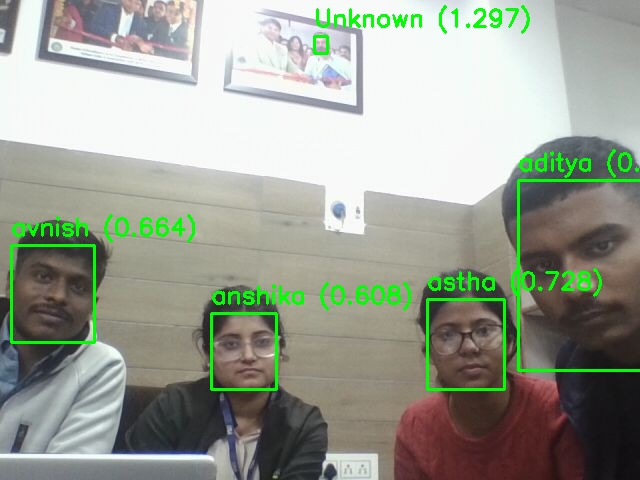

In [77]:
from google.colab.patches import cv2_imshow
import cv2

img = cv2.imread("output_final.jpg")
cv2_imshow(img)


#masked

In [99]:
from IPython.display import Javascript, display
from google.colab.output import eval_js
from base64 import b64decode

# Function to capture image from webcam in Colab

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = '📸 Capture';
          div.appendChild(capture);
          document.body.appendChild(div);

          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          document.body.appendChild(video);
          video.srcObject = stream;
          await video.play();

          // Wait for button click
          await new Promise((resolve) => capture.onclick = resolve);

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getVideoTracks()[0].stop();

          const dataUrl = canvas.toDataURL('image/jpeg', quality);
          div.remove();
          video.remove();
          return dataUrl;
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

         # Save image to disk

    with open(filename, 'wb') as f:
        f.write(binary)
    return filename


In [101]:
filename = take_photo()
print("📷 Photo saved as:", filename)



<IPython.core.display.Javascript object>

📷 Photo saved as: photo.jpg


In [102]:
# ===============================
# BUILDING EMBEDDING DATABASE
# ===============================

import os
import torch
import pickle
import numpy as np
from PIL import Image
from torchvision import transforms
from facenet_pytorch import InceptionResnetV1

# ---------------------------
# 1. SET DATASET PATH
# ---------------------------
dataset_path = "/content/drive/My Drive/face_dataset"
output_pickle = "/content/drive/My Drive/face_embeddings.pkl"

# ---------------------------
# 2. LOAD FACENET MODEL
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = InceptionResnetV1(pretrained='vggface2').eval().to(device)

# ---------------------------
# 3. IMAGE PREPROCESSOR
# ---------------------------
transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
])

# ---------------------------
# 4. START BUILDING DB
# ---------------------------
embedding_database = {}

for person in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person)

    if not os.path.isdir(person_path):
        continue

    print(f"\nProcessing person: {person}")
    embeddings = []

    for sub in ["mask", "unmask"]:
        sub_path = os.path.join(person_path, sub)
        if not os.path.isdir(sub_path):
            continue

        for img_name in os.listdir(sub_path):
            img_path = os.path.join(sub_path, img_name)

            # Skip folders or non-images
            if os.path.isdir(img_path):
                continue
            if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            try:
                img = Image.open(img_path).convert("RGB")
                img_tensor = transform(img).unsqueeze(0).to(device)

                with torch.no_grad():
                    emb = model(img_tensor).cpu().numpy()[0]

                embeddings.append(emb)
                print("✔ Embedded:", img_path)

            except Exception as e:
                print("⚠ Error:", img_path, e)

    if len(embeddings) > 0:
        embedding_database[person] = embeddings
        print(f"🎯 Stored {len(embeddings)} embeddings for {person}")
    else:
        print(f"❌ No valid images for {person}")

# ---------------------------
# 5. SAVE TO DISK
# ---------------------------
with open(output_pickle, "wb") as f:
    pickle.dump(embedding_database, f)

print("\n🎉 All embeddings saved at:", output_pickle)



Processing person: aditya
✔ Embedded: /content/drive/My Drive/face_dataset/aditya/mask/WhatsApp Image 2025-11-21 at 12.54.31_976ead59.jpg
✔ Embedded: /content/drive/My Drive/face_dataset/aditya/mask/WhatsApp Image 2025-11-21 at 12.54.32_d9c03418.jpg
✔ Embedded: /content/drive/My Drive/face_dataset/aditya/mask/WhatsApp Image 2025-11-21 at 12.54.30_0bc329c5.jpg
✔ Embedded: /content/drive/My Drive/face_dataset/aditya/unmask/aditya.jpg
✔ Embedded: /content/drive/My Drive/face_dataset/aditya/unmask/WhatsApp Image 2025-11-21 at 12.54.33_defac223.jpg
✔ Embedded: /content/drive/My Drive/face_dataset/aditya/unmask/WhatsApp Image 2025-11-21 at 12.54.34_18ffa9eb.jpg
✔ Embedded: /content/drive/My Drive/face_dataset/aditya/unmask/WhatsApp Image 2025-11-21 at 12.54.35_e541d4df.jpg
🎯 Stored 7 embeddings for aditya

Processing person: anshika
✔ Embedded: /content/drive/My Drive/face_dataset/anshika/mask/WhatsApp Image 2025-11-21 at 12.55.19_7706d8fb.jpg
✔ Embedded: /content/drive/My Drive/face_datase

In [103]:
# create_database.py
import os
import pickle
import numpy as np
import torch
from PIL import Image
from facenet_pytorch import MTCNN, InceptionResnetV1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# MTCNN configured to return aligned 160x160 face tensors
mtcnn = MTCNN(image_size=160, margin=0, keep_all=False, post_process=True, device=device)

# FaceNet model
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

dataset_path = "/content/drive/My Drive/face_dataset"
out_path = "/content/drive/My Drive/face_embeddings_mean.pkl"

database = {}

for person in os.listdir(dataset_path):
    person_dir = os.path.join(dataset_path, person)
    if not os.path.isdir(person_dir):
        continue

    print(f"\nProcessing: {person}")
    emb_list = []

    # traverse mask & unmask subfolders (if you have others, os.walk is fine)
    for sub in ["mask", "unmask"]:
        sub_dir = os.path.join(person_dir, sub)
        if not os.path.isdir(sub_dir):
            continue

        for fname in os.listdir(sub_dir):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            img_path = os.path.join(sub_dir, fname)
            try:
                img = Image.open(img_path).convert("RGB")
            except Exception as e:
                print("  Failed open:", img_path, e)
                continue

            # detect & get aligned face tensor (3x160x160) or None
            face_tensor = mtcnn(img)   # returns torch.Tensor (3,160,160) or None

            if face_tensor is None:
                print("  No face detected:", img_path)
                continue

            # Prepare batch dim and get embedding
            face_tensor = face_tensor.unsqueeze(0).to(device)   # (1,3,160,160)
            with torch.no_grad():
                emb = resnet(face_tensor)                       # (1,512)
            emb = emb.cpu().numpy().reshape(-1)

            # Normalize (L2)
            emb = emb / np.linalg.norm(emb)
            emb_list.append(emb)
            print("  Embedded:", img_path)

    if len(emb_list) == 0:
        print("  WARNING: no valid faces for", person)
        continue

    # Compute mean (centroid) and normalize again
    mean_emb = np.mean(np.vstack(emb_list), axis=0)
    mean_emb = mean_emb / np.linalg.norm(mean_emb)

    database[person] = {
        "mean": mean_emb,
        "n_images": len(emb_list)
    }
    print(f"  Stored mean embedding for {person} (n={len(emb_list)})")

# Save database
with open(out_path, "wb") as f:
    pickle.dump(database, f)

print("\nSaved database to:", out_path)
print("Persons:", list(database.keys()))



Processing: aditya
  Embedded: /content/drive/My Drive/face_dataset/aditya/mask/WhatsApp Image 2025-11-21 at 12.54.31_976ead59.jpg
  Embedded: /content/drive/My Drive/face_dataset/aditya/mask/WhatsApp Image 2025-11-21 at 12.54.32_d9c03418.jpg
  Embedded: /content/drive/My Drive/face_dataset/aditya/mask/WhatsApp Image 2025-11-21 at 12.54.30_0bc329c5.jpg
  Embedded: /content/drive/My Drive/face_dataset/aditya/unmask/aditya.jpg
  Embedded: /content/drive/My Drive/face_dataset/aditya/unmask/WhatsApp Image 2025-11-21 at 12.54.33_defac223.jpg
  Embedded: /content/drive/My Drive/face_dataset/aditya/unmask/WhatsApp Image 2025-11-21 at 12.54.34_18ffa9eb.jpg
  Embedded: /content/drive/My Drive/face_dataset/aditya/unmask/WhatsApp Image 2025-11-21 at 12.54.35_e541d4df.jpg
  Stored mean embedding for aditya (n=7)

Processing: anshika
  No face detected: /content/drive/My Drive/face_dataset/anshika/mask/WhatsApp Image 2025-11-21 at 12.55.19_7706d8fb.jpg
  Embedded: /content/drive/My Drive/face_data

In [104]:
# identify_face.py
import pickle
import numpy as np
import cv2
from PIL import Image
import torch
from facenet_pytorch import MTCNN, InceptionResnetV1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load DB (mean embeddings)
db_path = "/content/drive/My Drive/face_embeddings_mean.pkl"
with open(db_path, "rb") as f:
    database = pickle.load(f)

print("Loaded persons:", list(database.keys()))

# Detector and embedder (same config as create)
detector = MTCNN(image_size=160, margin=0, keep_all=True, post_process=True, device=device)
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

def get_face_tensors(pil_img):
    faces = detector(pil_img)

    if faces is None:
        return []

    # MTCNN behavior:
    # if keep_all=True:
    #   - IF 1 face → returns Tensor (3,160,160)
    #   - IF multiple → returns list of Tensors
    # So we normalize both cases:

    out = []

    if isinstance(faces, torch.Tensor):
        # Single face → (3,160,160)
        if faces.ndim == 3:
            out.append(faces)

        # WRONG CASE → (3,3,160,160) or (N,3,160,160)
        elif faces.ndim == 4:
            for i in range(faces.shape[0]):
                out.append(faces[i])

    elif isinstance(faces, list):
        # Multiple faces already → append all
        for f in faces:
            if f is not None:
                out.append(f)

    return out


def get_embedding_from_tensor(face_tensor):
    t = face_tensor.unsqueeze(0).to(device)  # (1,3,160,160)
    with torch.no_grad():
        emb = resnet(t)
    emb = emb.cpu().numpy().reshape(-1)
    emb = emb / np.linalg.norm(emb)
    return emb

def identify(emb, top_k=3):
    # compute Euclidean distance (on normalized vectors, equivalently cosine)
    results = []
    for name, meta in database.items():
        db_emb = meta["mean"]
        dist = np.linalg.norm(emb - db_emb)
        results.append((name, dist))
    results.sort(key=lambda x: x[1])
    return results[:top_k]   # list of (name, dist)

# TUNE this threshold (on normalized embeddings)
THRESHOLD = 0.9   # smaller is stricter; try 0.8..1.1 depending on your set

# ---------------------------
# Run on test image
# ---------------------------
img_path = "photo.jpg"   # change to your path
pil = Image.open(img_path).convert("RGB")

face_tensors = get_face_tensors(pil)

img_cv = cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)

if len(face_tensors) == 0:
    print("No faces detected.")
else:
    for i, face_tensor in enumerate(face_tensors, start=1):
        emb = get_embedding_from_tensor(face_tensor)
        top_matches = identify(emb, top_k=3)

        best_name, best_dist = top_matches[0]

        # Decide recognized vs unknown
        label = f"{best_name} ({best_dist:.3f})" if best_dist < THRESHOLD else f"Unknown ({best_dist:.3f})"

        # For drawing, we need bounding box -> use detector.detect to get boxes
        boxes, probs = detector.detect(pil)
        if boxes is not None:
            box = boxes[i-1]   # match ordering
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img_cv, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img_cv, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        else:
            # fallback: just print
            print("Face", i, "->", label)

        # Debug: print top3
        print(f"\nFace {i} TOP MATCHES:")
        for rank, (name, dist) in enumerate(top_matches, start=1):
            print(f"  {rank}. {name}  dist={dist:.4f}")

    cv2.imwrite("mask_output_final.jpg", img_cv)
    print("\nSaved mask_output_final.jpg")


Loaded persons: ['aditya', 'anshika', 'avnish', 'astha']

Face 1 TOP MATCHES:
  1. aditya  dist=0.6833
  2. avnish  dist=1.1894
  3. astha  dist=1.3070

Face 2 TOP MATCHES:
  1. avnish  dist=0.8964
  2. aditya  dist=1.2714
  3. astha  dist=1.3987

Face 3 TOP MATCHES:
  1. astha  dist=0.7586
  2. anshika  dist=1.0397
  3. avnish  dist=1.1563

Face 4 TOP MATCHES:
  1. anshika  dist=0.7493
  2. astha  dist=0.9845
  3. avnish  dist=1.3303

Face 5 TOP MATCHES:
  1. anshika  dist=1.2790
  2. aditya  dist=1.3542
  3. astha  dist=1.3692

Saved mask_output_final.jpg


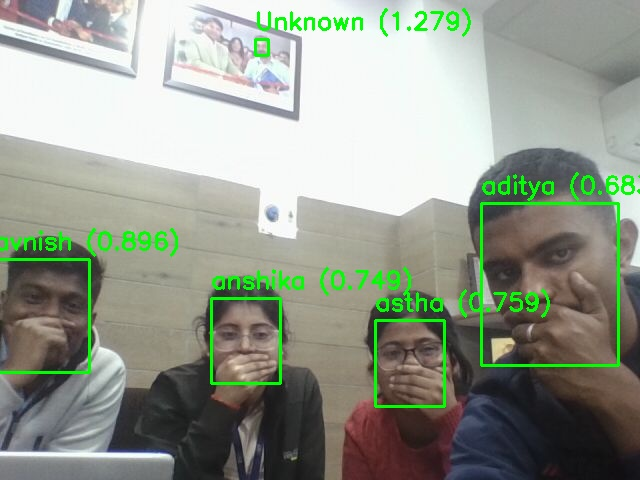

In [105]:
from google.colab.patches import cv2_imshow
import cv2

img = cv2.imread("mask_output_final.jpg")
cv2_imshow(img)
